In [3]:
# Importar librerías
import wooldridge as wd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Cargar el dataset wage1 de Wooldridge
df_prostata_prostata_prostata = wd.data('wage2')

display(df_prostata)

NameError: name 'df_prostata' is not defined

In [ ]:
df_prostata.columns

In [ ]:
# Definir variables
X = df_prostata['age'].values  # Variable independiente (edad)
y = df_prostata['wage'].values  # Variable dependiente (ingreso)

# Agregar columna de unos para la intersección (X_0 = 1)
X_with_intercept = np.c_[np.ones(X.shape[0]), X]

# Calcular coeficientes usando la ecuación matricial OLS: β = (X'X)^(-1) X'Y
beta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y

# Obtener predicciones
y_pred = X_with_intercept @ beta

### 1️⃣ MSE usando la ecuación tradicional (escalar)
mse_scalar = np.mean((y - y_pred) ** 2)

### 2️⃣ MSE usando la forma matricial
n = len(y)  # Número de observaciones
mse_matrix = (1/n) * ((y - y_pred).T @ (y - y_pred))

# Mostrar resultados redondeados a 2 decimales
print("Coeficientes del modelo (beta):", np.round(beta, 2))
print("MSE (Ecuación tradicional):", round(mse_scalar, 2))
print("MSE (Forma matricial):", round(mse_matrix, 2))

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Simulación de datos
np.random.seed(42)
n_samples, n_features = 100, 10
X = np.random.randn(n_samples, n_features)
y = X @ np.array([3, -2, 0, 5, 0, 0, -1, 4, 0, 2]) + np.random.randn(n_samples) * 0.5

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Rango de valores de lambda (alpha en sklearn)
lambdas = np.logspace(-2, 2, 50)

# Almacenar coeficientes
coef_lasso = []
coef_ridge = []

for alpha in lambdas:
    lasso = Lasso(alpha=alpha)
    ridge = Ridge(alpha=alpha)
    
    lasso.fit(X_scaled, y)
    ridge.fit(X_scaled, y)
    
    coef_lasso.append(lasso.coef_)
    coef_ridge.append(ridge.coef_)

# Convertir a DataFrame para Plotly
def format_coefs(coefs, method):
    df_prostata = pd.DataFrame(coefs, columns=[f'Feature {i+1}' for i in range(n_features)])
    df_prostata['Lambda'] = lambdas
    df_prostata = df_prostata.melt(id_vars=['Lambda'], var_name='Feature', value_name='Coefficient')
    df_prostata['Method'] = method
    return df_prostata

df_prostata_lasso = format_coefs(coef_lasso, 'Lasso (L1)')
df_prostata_ridge = format_coefs(coef_ridge, 'Ridge (L2)')

df_prostata = pd.concat([df_prostata_lasso, df_prostata_ridge])

# Gráfico interactivo
fig = px.line(df_prostata, x='Lambda', y='Coefficient', color='Feature', facet_col='Method', 
              title='Regularización L1 (Lasso) vs L2 (Ridge)', 
              log_x=True, template='plotly_dark')
fig.show()

<div style="background-color: #cce5ff; border-color: #b8daff; color: #004085; padding: 15px; border-radius: 5px; font-size: 24px;">
    <i class="fa fa-list-ol" aria-hidden="true"></i> <b></b> Ejemplos con el dataset de <b>prostata.CSV</b> para las penalizaciones de Riddge y/o Lasso:
</div>

In [39]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
import pyreadr
import os
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir("C:/Users/marcelochavez/Documents/DATA_SCIENCE_ENDI/")

# Cargar el archivo .rda
df_prostata = pd.DataFrame(pyreadr.read_r('NOTEBOOKS_R/DATASETS/Prostate.rda')['Prostate'])
display(df_prostata)

# Seleccionar variables predictoras y la respuesta
X = df_prostata[['lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45']]
y = df_prostata['lpsa']

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Rango de valores de lambda (alpha en sklearn) de 0.01 a 5
lambdas = np.linspace(0.01, 5, 50)  # Cambiar aquí para que vaya de 0.01 a 5

# Almacenar coeficientes
coef_lasso = []
coef_ridge = []

for alpha in lambdas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    ridge = Ridge(alpha=alpha)
    
    lasso.fit(X_scaled, y)
    ridge.fit(X_scaled, y)
    
    coef_lasso.append(lasso.coef_)
    coef_ridge.append(ridge.coef_)

# Convertir a DataFrame para Plotly
def format_coefs(coefs, method):
    df_coefs = pd.DataFrame(coefs, columns=X.columns)  # Usa los nombres originales de las columnas
    df_coefs['Lambda'] = lambdas
    df_coefs = df_coefs.melt(id_vars=['Lambda'], var_name='Feature', value_name='Coefficient')
    df_coefs['Method'] = method
    return df_coefs

df_prostata_lasso = format_coefs(coef_lasso, 'Lasso (L1)')
df_prostata_ridge = format_coefs(coef_ridge, 'Ridge (L2)')

df_prostata = pd.concat([df_prostata_lasso, df_prostata_ridge])

# Verificar los nombres de las columnas
print(df_prostata.columns)  # Asegúrate de que 'Lambda' está presente

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50.0,-1.386294,0.0,-1.386294,6.0,0.0,-0.430783
1,-0.994252,3.319626,58.0,-1.386294,0.0,-1.386294,6.0,0.0,-0.162519
2,-0.510826,2.691243,74.0,-1.386294,0.0,-1.386294,7.0,20.0,-0.162519
3,-1.203973,3.282789,58.0,-1.386294,0.0,-1.386294,6.0,0.0,-0.162519
4,0.751416,3.432373,62.0,-1.386294,0.0,-1.386294,6.0,0.0,0.371564
...,...,...,...,...,...,...,...,...,...
92,2.830268,3.876396,68.0,-1.386294,1.0,1.321756,7.0,60.0,4.385147
93,3.821004,3.896909,44.0,-1.386294,1.0,2.169054,7.0,40.0,4.684443
94,2.907447,3.396185,52.0,-1.386294,1.0,2.463853,7.0,10.0,5.143124
95,2.882564,3.773910,68.0,1.558145,1.0,1.558145,7.0,80.0,5.477509


Index(['Lambda', 'Feature', 'Coefficient', 'Method'], dtype='object')


In [40]:
# Gráfico interactivo
fig = px.line(df_prostata,
              x='Lambda', 
              y='Coefficient',
              color='Feature', 
              facet_col='Method', 
              title='Regularización L1 (Lasso) vs L2 (Ridge) - Prostate Dataset', 
              log_x=False,  # Cambiar a False para mostrar la escala lineal
              template='simple_white')

# Ajustar los límites del eje X y Y
fig.update_xaxes(range=[0, 1], dtick=0.1)  # Establecer el rango del eje X de 0 a 5 y ticks en intervalos de 0.1
fig.update_yaxes(range=[-0.2, 1], dtick=0.1)  # Establecer el rango del eje Y de -1 a 1

fig.show()

<Figure size 1200x600 with 0 Axes>

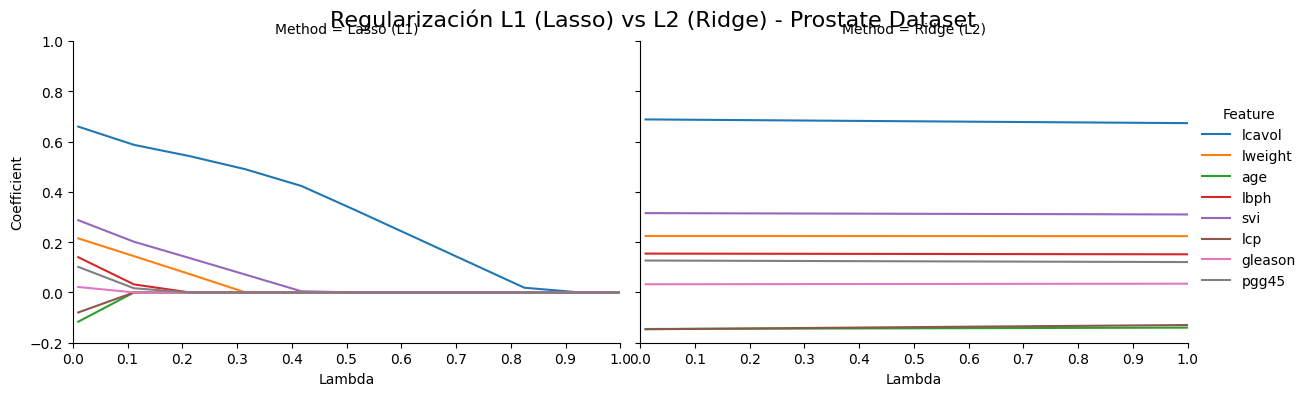

In [42]:
# Gráfico con Seaborn
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(df_prostata, col='Method', hue='Feature', height=4, aspect=1.5)
g.map(sns.lineplot, 'Lambda', 'Coefficient')

# Ajustar límites y ticks de los ejes
for ax in g.axes.flatten():
    ax.set(yscale='linear', xlim=(0, 1), ylim=(-0.2, 1))
    ax.set_xticks(np.arange(0, 1.1, 0.1))  # Establecer ticks en el eje X
    ax.set_xticklabels(np.round(np.arange(0, 1.1, 0.1), 1))

g.add_legend()
g.fig.suptitle('Regularización L1 (Lasso) vs L2 (Ridge) - Prostate Dataset', fontsize=16)
g.fig.subplots_adjust(top=0.9)  # Ajustar el título
plt.show()